# Fourier Epicycles: drawing *Castel del Monte*

This notebook reconstructs the outline of *Castel del Monte* using the
Discrete Fourier Transform (DFT). The ordered coordinates of the drawing are
interpreted as samples of a complex-valued periodic signal, whose Fourier
coefficients define a chain of rotating epicycles.

The notebook covers curve preprocessing, uniform arc-length resampling,
Fourier decomposition, reconstruction, and the final epicycle animation.

The mathematical approach follows the method described in
[the reference paper](https://mathed.miamioh.edu/index.php/ggbj/article/view/197/159).

In [56]:
# Import all the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.animation import FFMpegWriter, FuncAnimation

## Input Curve

The input CSV file contains an ordered sequence of two-dimensional
coordinates tracing the outline of *Castel del Monte*.

The points describe a closed curve: consecutive points follow a continuous
path, and the final point reconnects to the initial point without a spatial
discontinuity. Some portions of the drawing are intentionally traced more
than once, allowing the complete shape to be represented as a single
continuous path.

A closed curve is particularly convenient for Fourier analysis because the
Discrete Fourier Transform treats the sampled coordinates as one period of
a periodic signal. Therefore, the transition from the last sample back to
the first should be continuous.

Open curves, such as freehand drawings, can also be represented with Fourier
epicycles. However, the DFT implicitly connects the final point back to the
initial one. If these points are far apart, this introduces a discontinuity
at the period boundary, which may require additional high-frequency
components and produce oscillations near the closing segment. Possible
solutions include adding a return path, retracing part of the drawing, or
otherwise designing a continuous connection between the endpoints.

In [57]:

file_path = "castel_del_monte.csv"

# Read the ordered outline points from CSV
df_points = pd.read_csv(file_path)

In [58]:
# check dataframe
print(df_points.head())
print(df_points.tail())
print("Number of points:", len(df_points))

   index      x      y
0      0  129.0 -272.0
1      1  130.0 -273.0
2      2  131.0 -274.0
3      3  132.0 -274.0
4      4  133.0 -275.0
      index      x      y
4039   4039  129.0 -268.0
4040   4040  129.0 -269.0
4041   4041  129.0 -270.0
4042   4042  129.0 -271.0
4043   4043  129.0 -272.0
Number of points: 4044


Text(0.5, 1.0, '$\\it{Castel\\ Del\\ Monte}$: original drawing points')

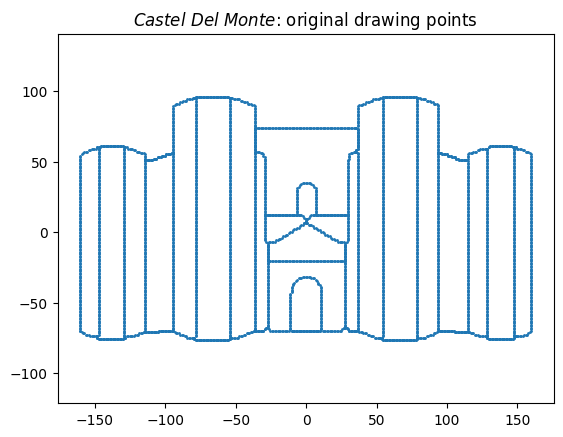

In [59]:
#extract the coordinates and center them around the origin

x = np.array(df_points['x']-df_points['x'].mean())
y = np.array((df_points['y']-df_points['y'].mean()))

plt.scatter(x, y,s=1)
plt.axis("equal")
plt.title(r"$\it{Castel\ Del\ Monte}$: original drawing points")

## Uniform Arc-Length Resampling

The original curve contains a large number of ordered points sampled on a
pixel grid. Although these points describe a continuous path, they are not
equally spaced in Euclidean distance: horizontal and vertical steps have
length $1$, whereas diagonal steps have length $\sqrt{2}$.

Before computing the Discrete Fourier Transform, the curve is therefore
resampled at approximately uniform arc-length intervals. This gives every
portion of the curve a more consistent representation and prevents regions
with a higher sampling density from having a disproportionately large
influence on the Fourier coefficients.

The number of samples is reduced from the original dataset to

$$
N = 1024 = 2^{10}.
$$

This value provides a practical compromise: it substantially reduces the
computational cost of the Fourier analysis while retaining enough detail to
reconstruct the outline of *Castel del Monte*.

Although $N$ is a power of two, this notebook does not use the Fast Fourier
Transform. Instead, the DFT is implemented directly from its mathematical
definition to show explicitly how the Fourier formulas translate into
Python code. Choosing $N=1024$ also keeps the dataset compatible with a
possible future FFT-based implementation.

Following the construction presented by Ponce Campuzano, the resampled curve
is represented by $N$ complex points

$$
p_n = x_n + i y_n,
\qquad n=0,1,\ldots,N-1,
$$

where $x_n$ and $y_n$ are the Cartesian coordinates of the $n$-th sample.
The sequence

$$
\{p_0,p_1,\ldots,p_{N-1}\}
$$

represents one period of the closed curve. The samples are distributed at
approximately uniform arc-length intervals, and the initial point is not
duplicated at the end.

In [60]:
#calculate the distances between consecutive points
def get_distances(x,y):
    return np.sqrt(((x[1:]-x[:-1])**2 + (y[1:]-y[:-1])**2))

distances = get_distances(x,y)

# get the total length of the curve
total_curve_length = distances.sum()

In [61]:
# number of outline samples
n_samples=1024

In [62]:
# arc-length between samples
ds = total_curve_length/n_samples

In [63]:
# Resampling the Curve

# coordinates of the resampled curve
x_coord = []
y_coord = []

x_coord.append(x[0])
y_coord.append(y[0])


# For each target distance along the curve, `find_interval` identifies the
# original segment containing that position. The new (x,y) point is then obtained by
# linear interpolation along the selected segment
def find_interval(distances,distance):
    cumulative_distance = 0
    for i in range(len(distances)):
        cumulative_distance+=distances[i]
        if distance<cumulative_distance:
            return i
    return len(distances)-1
        

# perform resampling

cumulative_distance = ds
for i in range(1,n_samples):
    j = find_interval(distances,cumulative_distance)
    dy = (y[j+1]-y[j])
    dx = (x[j+1]-x[j])
    alpha = np.atan2(dy,dx)
    x_coord.append(x[j]+(cumulative_distance-distances[:j].sum())*np.cos(alpha))
    y_coord.append(y[j]+(cumulative_distance-distances[:j].sum())*np.sin(alpha))
    cumulative_distance+=ds
        
        
# resampled coordinates as numpy arrays        
x_coord = np.array(x_coord)
y_coord = np.array(y_coord)

Text(0.5, 1.0, '$\\it{Castel\\ Del\\ Monte}$: resampled points')

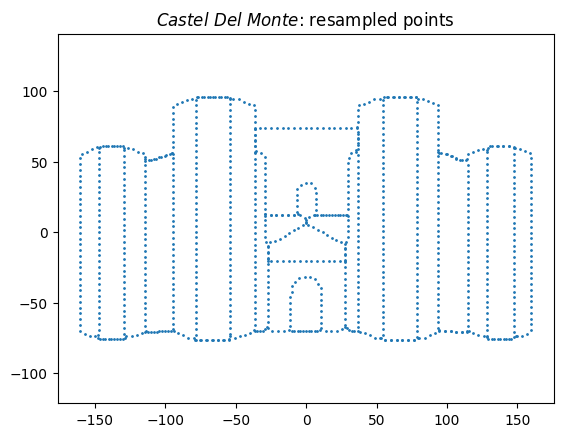

In [64]:
plt.scatter(x_coord, y_coord,s=1)
plt.axis("equal")
plt.title(r"$\it{Castel\ Del\ Monte}$: resampled points")

## Discrete Fourier Transform

Following the reference paper, the resampled curve is interpreted as a
sequence of complex points

$$
p_n = x_n + i y_n,
\qquad n=0,1,\ldots,N-1.
$$

The corresponding Fourier coefficients are defined by

$$
X_k =
\frac{1}{N}
\sum_{n=0}^{N-1}
p_n e^{-i 2\pi kn/N},
\qquad k=0,1,\ldots,N-1.
$$

Using Euler's identity,

$$
e^{-i\theta} = \cos(\theta)-i\sin(\theta),
$$

and substituting $p_n=x_n+i y_n$, each term can be expanded as

$$
p_n e^{-i\theta}
=
(x_n+i y_n)(\cos\theta-i\sin\theta).
$$

Separating its real and imaginary parts gives

$$
\operatorname{Re}(X_k)
=
\frac{1}{N}
\sum_{n=0}^{N-1}
\left[
x_n\cos(\theta_{kn})
+
y_n\sin(\theta_{kn})
\right],
$$

and

$$
\operatorname{Im}(X_k)
=
\frac{1}{N}
\sum_{n=0}^{N-1}
\left[
y_n\cos(\theta_{kn})
-
x_n\sin(\theta_{kn})
\right],
$$

where

$$
\theta_{kn}=\frac{2\pi kn}{N}.
$$

The implementation below evaluates these sums directly. In the code,
`alpha` is negative,

$$
\alpha_k=-\frac{2\pi k}{N},
$$

so that `n_alpha` corresponds to $-\theta_{kn}$. Because cosine is even and
sine is odd, the expressions used in the code are equivalent to the DFT
formula above.

Each complex coefficient $X_k$ determines the geometric properties of one
epicycle. Its radius is the modulus

$$
R_k = |X_k|
=
\sqrt{
\operatorname{Re}(X_k)^2+
\operatorname{Im}(X_k)^2
},
$$

while its initial phase is

$$
\phi_k =
\arg(X_k)
=
\operatorname{atan2}
\left(
\operatorname{Im}(X_k),
\operatorname{Re}(X_k)
\right).
$$

The standard DFT indices $k=0,\ldots,N-1$ are finally mapped to signed
frequencies. Indices in the second half of the spectrum represent negative
rotations:

$$
f_k =
\begin{cases}
k, & k \leq N/2,\\
k-N, & k > N/2.
\end{cases}
$$

The function therefore stores each Fourier component as

$$
[f_k,\ R_k,\ \phi_k],
$$

corresponding respectively to the angular frequency, radius, and initial
phase of an epicycle.

In [65]:
def dft(x,y):
    N = len(x)
    X = []
    for k in range(N):
        re = 0.0
        im = 0.0
        alpha = -(2*np.pi*k)/N
        for n in range(N):
            n_alpha = n*alpha
            re += x[n]*np.cos(n_alpha)-y[n]*np.sin(n_alpha)
            im += x[n]*np.sin(n_alpha)+y[n]*np.cos(n_alpha)
        re = re/N
        im = im/N
        module = np.sqrt(re**2+im**2)
        phase = np.atan2(im,re)
        
        if k<=N/2:
            freq = k
        else:
            freq = k-N
        
        X.append([freq,module,phase])
    
    return X


    

In [66]:
# compute the DFT of the resampled points
castel_del_monte_dft = dft(x_coord,y_coord)

## Verifying the Fourier Reconstruction

Before constructing the animation, we verify that the manually implemented
DFT correctly represents the resampled curve.

The input consists of $N$ complex samples

$$
p_n=x_n+i y_n,
\qquad n=0,1,\ldots,N-1,
$$

where $n$ is the discrete sample index and $x_n$, $y_n$ are the Cartesian
coordinates of the $n$-th point.

### The DFT

Using the normalization convention adopted in this notebook, the Discrete
Fourier Transform is

$$
X_k=
\frac{1}{N}
\sum_{n=0}^{N-1}
p_n e^{-i2\pi kn/N},
\qquad k=0,1,\ldots,N-1.
$$

Each coefficient $X_k$ measures the contribution of the discrete frequency
indexed by $k$.

### The inverse DFT

The original samples can be recovered through the inverse Discrete Fourier
Transform:

$$
p_n=
\sum_{k=0}^{N-1}
X_k e^{i2\pi kn/N},
\qquad n=0,1,\ldots,N-1.
$$

The DFT decomposes the sampled curve into complex oscillations, while the
IDFT adds those oscillations together to reconstruct every original sample
$p_n$.

The phase appearing in each term of the IDFT is

$$
\frac{2\pi kn}{N}
=
k\left(\frac{2\pi n}{N}\right).
$$

This expression suggests defining

$$
t_n=\frac{2\pi n}{N}.
$$

With this notation, the IDFT becomes

$$
p_n=
\sum_{k=0}^{N-1}
X_k e^{ik t_n}.
$$

### Why does $t$ range from $0$ to $2\pi$?

The complex exponential

$$
e^{it}=\cos(t)+i\sin(t)
$$

describes one complete counterclockwise rotation around the unit circle as
$t$ varies from $0$ to $2\pi$.

Because the input represents one complete traversal of a closed curve, it is
natural to associate its $N$ samples with $N$ equally spaced angular
positions over one full revolution:

$$
t_n=\frac{2\pi n}{N},
\qquad n=0,1,\ldots,N-1.
$$

The spacing between consecutive parameter values is therefore

$$
\Delta t=\frac{2\pi}{N}.
$$

The first sample corresponds to

$$
t_0=0,
$$

while the last sample corresponds to

$$
t_{N-1}=2\pi-\frac{2\pi}{N}.
$$

The value $t=2\pi$ is not included because it represents the same angular
position as $t=0$:

$$
e^{i2\pi}=e^{i0}=1.
$$

Including both endpoints would therefore duplicate the first sample.

### From the IDFT to a continuous curve

The IDFT reconstructs the curve only at the discrete parameter values
$t_n$. To obtain a continuous interpolation, we replace the discrete
parameter $t_n$ with a continuous variable

$$
t\in[0,2\pi).
$$

This gives the trigonometric interpolant

$$
z(t)=
\sum_{k=0}^{N-1}
X_k e^{ik t}.
$$

At the sampled parameter values, this continuous function reduces exactly
to the IDFT:

$$
z(t_n)
=
\sum_{k=0}^{N-1}
X_k e^{ik t_n}
=
p_n.
$$

Thus, $z(t)$ passes through all the original resampled points, up to
floating-point numerical error.

### Signed frequencies

The standard DFT uses indices

$$
k=0,1,\ldots,N-1.
$$

For the epicycle animation, the second half of the spectrum is represented
using negative frequencies:

$$
f_k=
\begin{cases}
k, & k\leq N/2,\\
k-N, & k>N/2.
\end{cases}
$$

This remapping does not change the reconstruction at the discrete sample
positions. Indeed,

$$
e^{i(k-N)t_n}
=
e^{ikt_n}e^{-iNt_n}.
$$

Since

$$
Nt_n=2\pi n,
$$

we have

$$
e^{-iNt_n}=e^{-i2\pi n}=1,
$$

and therefore

$$
e^{i(k-N)t_n}=e^{ikt_n}.
$$

The signed frequency $f_k$ is useful in the continuous reconstruction
because its sign explicitly determines the direction in which the
corresponding epicycle rotates.

The continuous reconstruction can consequently be written as

$$
z(t)=
\sum_{k=0}^{N-1}
X_k e^{if_k t}.
$$

### Radius and phase of each epicycle

Each Fourier coefficient can be expressed in polar form:

$$
X_k=R_k e^{i\phi_k},
$$

where

$$
R_k=|X_k|
$$

is the radius of the corresponding epicycle and

$$
\phi_k=\arg(X_k)
$$

is its initial phase.

Substituting the polar representation into the continuous reconstruction
gives

$$
z(t)
=
\sum_{k=0}^{N-1}
R_k e^{i(f_k t+\phi_k)}.
$$

Using Euler's identity, the Cartesian coordinates are

$$
x(t)
=
\sum_{k=0}^{N-1}
R_k\cos(f_k t+\phi_k),
$$

$$
y(t)
=
\sum_{k=0}^{N-1}
R_k\sin(f_k t+\phi_k).
$$

The function `compute_epicycles` evaluates these sums progressively. It
starts from the origin and adds every rotating vector tip-to-tail, storing
the intermediate endpoints of the epicycle chain. Its final element,

```python
points[-1]
```
is the reconstructed point $z(t)$.
Evaluating this function at the discrete values
$$
t=t_n=\frac{2\pi n}{N}
$$
must reproduce the resampled input:
$$
z(t_n)=p_n.
$$
Plotting the reconstructed points therefore provides a direct verification of the DFT implementation, the inverse reconstruction, the signed-frequency mapping, and the radius and phase associated with every epicycle.


In [67]:
# compute epicycles at time t

def compute_epicycles(dft, t):
    points = [[0.0, 0.0]]

    x = 0.0
    y = 0.0

    for freq, module, phase in dft:
        x = x + module * np.cos(freq * t + phase)
        y = y + module * np.sin(freq * t + phase)
        points.append([x, y])

    return points

In [68]:
castel_del_monte_xy = []
t = np.linspace(0,2.0*np.pi,n_samples,endpoint=False)

for i in t:
    points = np.array(compute_epicycles(castel_del_monte_dft, i))
    castel_del_monte_xy.append(points[-1])

castel_del_monte_xy = np.array(castel_del_monte_xy)

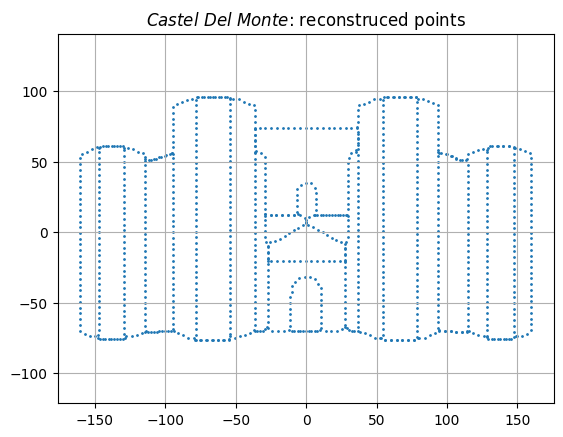

In [69]:
plt.scatter(castel_del_monte_xy[:, 0], castel_del_monte_xy[:, 1],s=1)
plt.axis("equal")
plt.grid(True)
plt.title(r"$\it{Castel\ Del\ Monte}$: reconstruced points")
plt.show()

## It works!

The reconstructed curve matches the resampled outline of *Castel del Monte*.
This confirms that the manually implemented DFT correctly recovers the
sampled signal and that the frequencies, radii, and phases are consistent.

## Building the Epicycle Animation

We can now use the Fourier coefficients to animate the reconstruction.

The animation is constructed through the following main steps:

1. The Fourier coefficients are sorted by decreasing modulus so that the
   largest and most visually relevant epicycles are placed first.

2. A limited number of coefficients is selected for displaying the epicycle
   chain. The complete set of coefficients is preserved for drawing the
   reconstructed curve accurately.

3. For every sampled value of $t$, the cumulative endpoints of the rotating
   Fourier vectors are precomputed. These points determine the centers of the
   circles and the endpoints of their radius vectors.

4. The figure limits are calculated from the complete motion of the
   epicycle chain, ensuring that circles remain inside the visible area
   throughout the animation.

5. Very small epicycles can be filtered according to their radius in screen
   pixels. The opacity of circles and vectors is also reduced for smaller
   radii to keep the visualization readable.

6. Matplotlib artists are created for the vectors, circles, moving tip, and
   accumulated trace.

7. An initialization function places all artists in their starting
   configuration, while an update function moves them at each animation
   frame and progressively reveals the reconstructed curve.

8. Finally, `FuncAnimation` generates the animation, which is exported as an
   MP4 video using the H.264 codec.

The following cells implement these steps. Most parameters controlling the
appearance and performance of the animation can be adjusted directly in the
corresponding code cells.

Text(0.5, 1.0, '$\\it{Castel\\ Del\\ Monte}$ and Fourier epicycles')

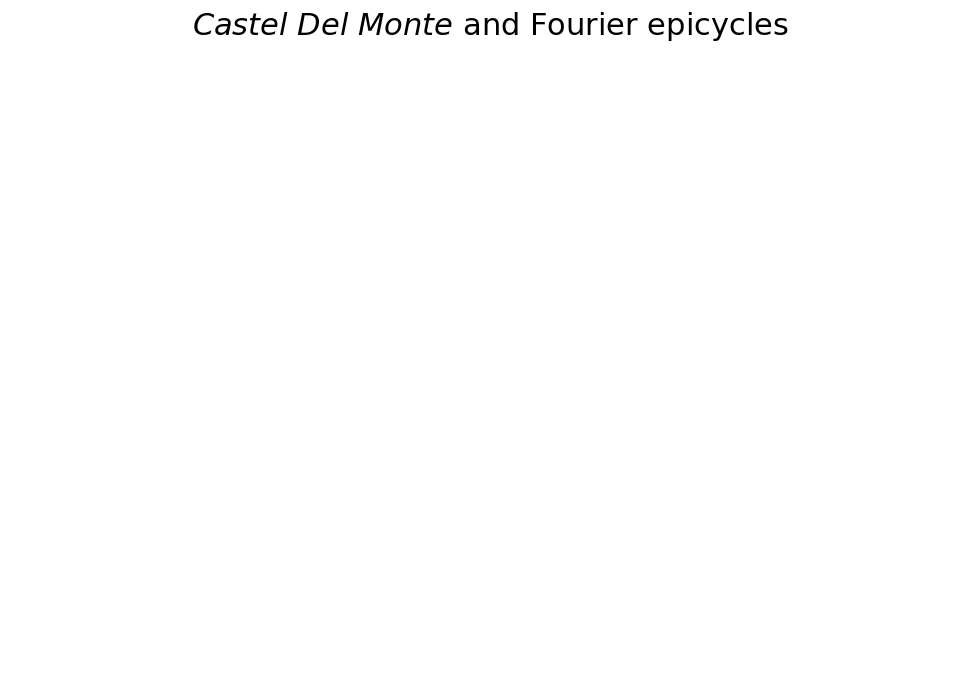

In [79]:
# Keep only the largest Fourier coefficients to represent the epicycles.
max_epicycles = 150
castel_del_monte_dft_animation = sorted(
    castel_del_monte_dft,
    key=lambda component: component[1],
    reverse=True
)[:max_epicycles]

# Animation settings.
duration = 30
fps = 30
n_frames = duration * fps

# Precompute every epicycle center and the final tip.
t_values = np.linspace(0, 2 * np.pi, n_samples, endpoint=False)
all_epicycles_centers_and_tip = np.array([
    compute_epicycles(castel_del_monte_dft_animation, t)
    for t in t_values
])

# Start from the limits of the reconstructed curve.
xmin = castel_del_monte_xy[:, 0].min()
xmax = castel_del_monte_xy[:, 0].max()
ymin = castel_del_monte_xy[:, 1].min()
ymax = castel_del_monte_xy[:, 1].max()

# Extend the limits to include every circle during the animation.
for i, (_, radius, _) in enumerate(castel_del_monte_dft_animation):
    centers = all_epicycles_centers_and_tip[:, i]
    xmin = min(xmin, (centers[:, 0] - radius).min())
    xmax = max(xmax, (centers[:, 0] + radius).max())
    ymin = min(ymin, (centers[:, 1] - radius).min())
    ymax = max(ymax, (centers[:, 1] + radius).max())

margin_x = 0.02 * (xmax - xmin)
margin_y = 0.02 * (ymax - ymin)

# Create the square figure.
fig, ax = plt.subplots(figsize=(10, 10))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.92)
ax.set_aspect("equal")
ax.set_xlim(xmin - margin_x, xmax + margin_x)
ax.set_ylim(ymin - margin_y, ymax + margin_y)
ax.axis("off")
ax.set_title(
    r"$\it{Castel\ Del\ Monte}$ and Fourier epicycles",
    fontsize=22,
    pad=12
)

In [80]:
fig.canvas.draw()  # Initialize the data-to-pixel transform
origin_px = ax.transData.transform((0.0, 0.0))

def radius_in_pixels(radius):
    radius_point_px = ax.transData.transform((radius, 0.0))
    return abs(radius_point_px[0] - origin_px[0])

# Nonlinear opacity in screen coordinates: above 20 px it remains nearly
# constant, then quickly drops to its minimum value at 0.75 px.
fade_start_px = 20.0
fade_end_px = 0.75
vector_alpha_min, vector_alpha_max = 0.3, 0.8
circle_alpha_min, circle_alpha_max = 0.0, 0.8

# Normalize the radius and apply the smoothstep function S(u) = u^2 * (3 - 2u), where u is the normalized radius in pixels
def nonlinear_radius_fade(module):
    radius_px = radius_in_pixels(module)
    value = (radius_px - fade_end_px) / (fade_start_px - fade_end_px)
    value = np.clip(value, 0.0, 1.0)
    return value * value * (3.0 - 2.0 * value)  # smoothstep

# Each vector connects one epicycle center to the next one.
# The final vector connects the last center to the drawing tip.
epicycle_vectors = []
for i, (_, module, _) in enumerate(castel_del_monte_dft_animation):
    fade = nonlinear_radius_fade(module)
    vector_alpha = vector_alpha_min + fade * (vector_alpha_max - vector_alpha_min)
    vector, = ax.plot([], [], color='black', lw=1, alpha=vector_alpha)
    epicycle_vectors.append((i, vector))

# Optional epicycle circles
show_circles = True
circle_patches = []

if show_circles:
    for i, (_, module, _) in enumerate(castel_del_monte_dft_animation):
        fade = nonlinear_radius_fade(module)
        circle_alpha = circle_alpha_min + fade * (circle_alpha_max - circle_alpha_min)
        circle = plt.Circle((0, 0), module, fill=False, color='orange', alpha=circle_alpha, lw=0.8)
        ax.add_patch(circle)
        circle_patches.append((i, circle))

# The tip and trace share exactly the same color.
trace_color = 'tab:blue'
tip_point, = ax.plot([], [], marker='o', linestyle='None', color=trace_color, ms=8)

# Accumulated trace
trace_line, = ax.plot([], [], color=trace_color, lw=2)



In [81]:
def init():
    for _, vector in epicycle_vectors:
        vector.set_data([], [])

    if show_circles:
        # Place every circle on the initial chain immediately; leaving them
        # all at (0, 0) creates concentric circles before the first update.
        initial_points = all_epicycles_centers_and_tip[0]
        for i, circle in circle_patches:
            circle.center = tuple(initial_points[i])

    tip_point.set_data([], [])
    trace_line.set_data([], [])

    artists = [vector for _, vector in epicycle_vectors] + [tip_point, trace_line]
    if show_circles:
        artists += [circle for _, circle in circle_patches]

    return artists

In [82]:
def update(frame):
    
    # Reserve the final frame for periodic curve closure.
    closing_frame = n_frames > 1 and frame == n_frames - 1
    if n_frames > 2 and not closing_frame:
        idx = round(frame * (n_samples - 1) / (n_frames - 2))
    else:
        idx = n_samples - 1

    # Use precomputed points instead of recalculating every frame.
    points = all_epicycles_centers_and_tip[0] if closing_frame else all_epicycles_centers_and_tip[idx]

    # Update vectors
    for i, vector in epicycle_vectors:
        x0, y0 = points[i]
        x1, y1 = points[i + 1]
        vector.set_data([x0, x1], [y0, y1])

    # Update circles
    if show_circles:
        for i, circle in circle_patches:
            x0, y0 = points[i]
            circle.center = (x0, y0)

    # Final tip
    tip_idx = 0 if closing_frame else idx
    x_tip, y_tip = castel_del_monte_xy[tip_idx]
    tip_point.set_data([x_tip], [y_tip])

    # The trace must use the complete Fourier reconstruction. all_points
    # instead uses castel_del_monte_dft_animation, limited by max_epicycles.
    trace_points = castel_del_monte_xy[:idx + 1]

    # Explicitly add the closing segment in the final frame.
    if closing_frame:
        trace_points = np.vstack((trace_points, castel_del_monte_xy[0]))

    trace_line.set_data(trace_points[:, 0], trace_points[:, 1])

    artists = [vector for _, vector in epicycle_vectors] + [tip_point, trace_line]
    if show_circles:
        artists += [circle for _, circle in circle_patches]

    return artists

In [83]:
anim = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    init_func=init,
    blit=True,
    interval=1000/fps,
    repeat=True
)

plt.show()

In [84]:
def progress_callback(current_frame, total_frames):
    percent = 100 * current_frame / total_frames

    if current_frame % 20 == 0:
        print(f"Salvataggio: {current_frame}/{total_frames} frame - {percent:.1f}%")

In [85]:
writer = FFMpegWriter(
    fps=fps,
    codec="libx264",
    extra_args=["-preset", "medium", "-crf", "20", "-pix_fmt", "yuv420p"]
)

In [86]:
anim.save(
    "epicycles.mp4",
    writer=writer,
    dpi=108,
    progress_callback=progress_callback
)

Salvataggio: 0/900 frame - 0.0%
Salvataggio: 20/900 frame - 2.2%
Salvataggio: 40/900 frame - 4.4%
Salvataggio: 60/900 frame - 6.7%
Salvataggio: 80/900 frame - 8.9%
Salvataggio: 100/900 frame - 11.1%
Salvataggio: 120/900 frame - 13.3%
Salvataggio: 140/900 frame - 15.6%
Salvataggio: 160/900 frame - 17.8%
Salvataggio: 180/900 frame - 20.0%
Salvataggio: 200/900 frame - 22.2%
Salvataggio: 220/900 frame - 24.4%
Salvataggio: 240/900 frame - 26.7%
Salvataggio: 260/900 frame - 28.9%
Salvataggio: 280/900 frame - 31.1%
Salvataggio: 300/900 frame - 33.3%
Salvataggio: 320/900 frame - 35.6%
Salvataggio: 340/900 frame - 37.8%
Salvataggio: 360/900 frame - 40.0%
Salvataggio: 380/900 frame - 42.2%
Salvataggio: 400/900 frame - 44.4%
Salvataggio: 420/900 frame - 46.7%
Salvataggio: 440/900 frame - 48.9%
Salvataggio: 460/900 frame - 51.1%
Salvataggio: 480/900 frame - 53.3%
Salvataggio: 500/900 frame - 55.6%
Salvataggio: 520/900 frame - 57.8%
Salvataggio: 540/900 frame - 60.0%
Salvataggio: 560/900 frame - 62